# 프로젝트 : mini BERT 만들기 (1M 파라미터)

한글 위키 코퍼스(kowiki)를 가공하여 BERT pretrain용 데이터셋(MLM + NSP)을 만들고,
**vocab size 8,000 / 전체 파라미터 약 1M**의 mini BERT를 구현하여 **10 Epoch** pretrain을 진행합니다.

## 루브릭 대응표

| 평가문항 | 상세기준 | 해당 섹션 |
|---|---|---|
| 1. 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다 | MLM, NSP task의 특징이 잘 반영된 데이터셋 생성과정이 체계적으로 진행 | 2 ~ 4단계 (단계별 동작 확인 + 통계 검증 포함) |
| 2. 구현한 BERT 모델의 학습이 안정적으로 진행됨을 확인하였다 | 학습 중 MLM, NSP loss의 안정적인 감소 확인 | 6단계 (학습 로그) + 7단계 (loss 곡선) |
| 3. 1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행되었다 | 학습된 모델 및 학습과정의 시각화 내역 제출 | 5단계 (파라미터 수 확인) + 7단계 (시각화, 체크포인트) |

> 실행 환경: **Google Colab (GPU 런타임)** 기준. `런타임 > 런타임 유형 변경 > GPU` 설정 후 실행하세요.

# 0. 환경 설정
---
데이터/모델 디렉토리를 만들고 한글 위키 코퍼스를 다운로드합니다.

In [1]:
!mkdir -p /content/data
!mkdir -p /content/models

In [2]:
# 한글 위키 코퍼스 다운로드 (약 150MB, 압축 해제 시 약 600MB)
!wget -nc https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -P /content/data
!cd /content/data && unzip -n kowiki.txt.zip

--2026-07-15 07:12:51--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.175.64.107, 3.175.64.105, 3.175.64.65, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.175.64.107|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘/content/data/kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M  87.5MB/s    in 2.7s    

2026-07-15 07:12:54 (87.5 MB/s) - ‘/content/data/kowiki.txt.zip’ saved [243123354/243123354]

Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


In [3]:
!pip install -q sentencepiece tqdm torchinfo

In [4]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import math
import random
import json
import copy
import collections
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

# 재현성을 위한 시드 고정
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

data_dir = '/content/data'
model_dir = '/content/models'
corpus_file = f'{data_dir}/kowiki.txt'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "/ device:", device)

torch: 2.11.0+cu128 / device: cuda


# 1. Tokenizer 준비
---
SentencePiece(BPE)로 **vocab_size 8,000**의 토크나이저를 학습합니다.

BERT pretrain에 필요한 특수 토큰 7개(`[PAD] [UNK] [BOS] [EOS] [SEP] [CLS] [MASK]`)를 반드시 vocab에 포함시킵니다.
`--vocab_size`에 `8000 + 7`을 지정해 특수 토큰을 제외한 실제 subword가 8,000개가 되도록 합니다.

> 학습에 10분 내외가 소요됩니다. (한 번 만들어 두면 재사용 가능)

In [5]:
prefix = f'{model_dir}/ko_8000'
vocab_size = 8000

if not os.path.exists(f'{prefix}.model'):
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}" +
        " --model_type=bpe" +
        " --max_sentence_length=999999" +
        " --pad_id=0 --pad_piece=[PAD]" +
        " --unk_id=1 --unk_piece=[UNK]" +
        " --bos_id=2 --bos_piece=[BOS]" +
        " --eos_id=3 --eos_piece=[EOS]" +
        " --user_defined_symbols=[SEP],[CLS],[MASK]")
    print("sentencepiece 모델 학습 완료")
else:
    print("이미 학습된 모델이 있습니다.")

sentencepiece 모델 학습 완료


In [6]:
# vocab 로딩 및 특수 토큰 확인
vocab = spm.SentencePieceProcessor()
vocab.load(f'{prefix}.model')

print("전체 vocab 크기:", len(vocab))
print("특수 토큰(0~6):", [vocab.id_to_piece(i) for i in range(7)])

# [MASK] 치환용 vocab_list (특수 토큰 7개와 unknown 제외)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print("vocab_list 크기:", len(vocab_list))

전체 vocab 크기: 8007
특수 토큰(0~6): ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]', '[CLS]', '[MASK]']
vocab_list 크기: 8000


In [7]:
# 토크나이저 동작 확인: [CLS] tokens_a [SEP] tokens_b [SEP] 형태 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
string_b = "첫 번에 삼십 전 둘째 번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"

tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print("token 수:", len(tokens_org))
print(tokens_org)

token 수: 53
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]']


✅ **검증 포인트(루브릭 1)** : vocab 크기가 8,007(= 8,000 subword + 특수 토큰 7개)이고, `[MASK]`, `[SEP]`, `[CLS]` 등 특수 토큰이 vocab에 포함되어 한글 문장이 subword 단위로 정상 토크나이징되는 것을 확인했습니다.

# 2. 데이터 전처리 (1) MASK 생성
---
BERT의 **Masked Language Model(MLM)** 학습 데이터를 만듭니다.

- 특수 토큰(`[CLS]`, `[SEP]`)을 제외한 전체 토큰의 **15%** 를 마스킹 대상으로 선정
- 선정된 토큰 중 **80%는 `[MASK]`**, **10%는 랜덤 토큰**, **10%는 원래 토큰 유지**
- subword 일부만 가리면 너무 쉽게 맞출 수 있으므로, `▁`(U+2581)로 시작하는 subword를 기준으로 **단어(띄어쓰기) 단위로 함께 마스킹**합니다.

In [8]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (▁ 시작 여부로 단어 경계 판단)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"▁"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음
    random.shuffle(cand_idx)

    mask_lms = []  # mask 된 값
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:  # 이미 목표 개수만큼 mask 했으면 중지
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # 이번 단어를 다 mask하면 목표 개수 초과 시 skip
            continue
        dice = random.random()  # 단어 단위로 주사위를 굴림
        for index in index_set:
            masked_token = None
            if dice < 0.8:  # 80% : [MASK] 치환
                masked_token = "[MASK]"
            elif dice < 0.9:  # 10% : 원래 토큰 유지
                masked_token = tokens[index]
            else:  # 10% : 랜덤 토큰 치환
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # index 순서로 정렬 후 mask_idx, mask_label 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

In [9]:
# 동작 확인: 마스킹 전/후 비교
tokens = copy.deepcopy(tokens_org)
mask_cnt = int((len(tokens) - 3) * 0.15)  # [CLS] 1개, [SEP] 2개 제외한 토큰의 15%

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("마스킹 전:", tokens_org)
print("마스킹 후:", tokens)
print("mask_idx  :", mask_idx)
print("mask_label:", mask_label)

마스킹 전: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]']
마스킹 후: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '[MASK]', '[MASK]', '[MASK]', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]']
mask_idx  : [18, 19, 20, 24, 36, 37, 38]
mask_label: ['▁손', '님', '이', '▁첫', '▁오', '랜', '만에']


In [10]:
# 통계 검증: 마스킹 규칙(15%, 80/10/10)이 실제로 지켜지는지 2,000회 시뮬레이션으로 확인
n_trials = 2000
ratios = []
kinds = {"[MASK] 치환": 0, "원본 유지": 0, "랜덤 치환": 0}

for _ in range(n_trials):
    t = copy.deepcopy(tokens_org)
    m_cnt = int((len(t) - 3) * 0.15)
    t, m_idx, m_label = create_pretrain_mask(t, m_cnt, vocab_list)
    ratios.append(len(m_idx) / (len(t) - 3))
    for idx, lab in zip(m_idx, m_label):
        if t[idx] == "[MASK]":
            kinds["[MASK] 치환"] += 1
        elif t[idx] == lab:
            kinds["원본 유지"] += 1
        else:
            kinds["랜덤 치환"] += 1

total = sum(kinds.values())
print(f"실측 마스킹 비율 평균: {np.mean(ratios):.3f} (목표 0.15 이하 근접, 단어 단위 마스킹 특성상 약간 낮게 나올 수 있음)")
for k, v in kinds.items():
    print(f"{k}: {v/total:.3f}")

실측 마스킹 비율 평균: 0.140 (목표 0.15 이하 근접, 단어 단위 마스킹 특성상 약간 낮게 나올 수 있음)
[MASK] 치환: 0.798
원본 유지: 0.102
랜덤 치환: 0.100


✅ **검증 포인트(루브릭 1)** : 시뮬레이션 결과 마스킹 대상 토큰 중 `[MASK]` 치환 / 원본 유지 / 랜덤 치환 비율이 **약 0.8 / 0.1 / 0.1**로, BERT 논문의 MLM 마스킹 전략이 정확히 구현되었음을 통계적으로 확인했습니다. (단어 단위 마스킹이라 실측 마스킹 비율은 15%보다 약간 낮게 측정될 수 있습니다.)

# 3. 데이터 전처리 (2) NSP pair 생성
---
BERT의 **Next Sentence Prediction(NSP)** 학습 데이터를 만듭니다.

- 문서 내에서 이어지는 두 문장 묶음(tokens_a, tokens_b)을 만들고, **50% 확률**로 순서를 뒤집어 `is_next=0(False)`, 그대로 두면 `is_next=1(True)` 라벨 부여
- `[CLS] tokens_a [SEP] tokens_b [SEP]` 구조로 연결하고, 첫 문장 구간은 **segment 0**, 두 번째 문장 구간은 **segment 1**
- 최대 길이 초과 시 `trim_tokens`로 길이 조절 (앞 문장은 앞에서, 뒷 문장은 뒤에서 제거)
- 마지막에 `create_pretrain_mask()`를 적용해 **MLM과 NSP가 동시에 학습되는** 데이터를 완성

In [11]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 (최대 길이: max_seq)
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]   # 긴 쪽이 A면 앞에서 제거
        else:
            tokens_b.pop()    # 긴 쪽이 B면 뒤에서 제거

In [12]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc(문서 1개)별 pretrain 데이터(MLM + NSP) 생성
    :param vocab: vocab
    :param doc: 줄 단위로 tokenize된 문서
    :param n_seq: 최대 시퀀스 길이
    :param mask_prob: 마스킹 비율 (0.15)
    :param vocab_list: 랜덤 치환용 vocab list
    """
    # [CLS], [SEP], [SEP] 3개 자리 확보
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        # 마지막 줄이거나 누적 길이가 max_seq 이상이면 instance 생성
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # chunk를 임의 지점(a_end)에서 A/B 두 부분으로 분할
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% 확률로 A/B 순서를 뒤집어 False 케이스 생성
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # [CLS] A [SEP] B [SEP] + segment (A구간 0, B구간 1)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # MLM 마스킹 적용 (MLM과 NSP 동시 학습용 데이터 완성)
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

In [13]:
# 동작 확인: 예시 문서로 instance 생성
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셨어"""

doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]

n_test_seq = 64
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
for instance in instances:
    print(json.dumps(instance, ensure_ascii=False, indent=None)[:300], "...")

{"tokens": ["[CLS]", "▁오", "랜", "만에", "▁받아", "보", "는", "▁십", "▁전", "짜", "리", "▁백", "통", "화", "[MASK]", "[MASK]", "[MASK]", "▁손", "바", "닥", "▁위", "엔", "▁기", "쁨", "의", "▁눈", "물이", "▁흘", "러", "[SEP]", "▁추", "적", "추", "적", "▁비", "가", "▁내", "리는", "▁날", "이었", "어", "▁그", "날", "은", "▁", "왠", "지", "[MASK]",  ...


In [14]:
# 통계 검증: NSP 라벨 분포와 instance 구조가 규칙대로 만들어지는지 500회 반복 생성으로 확인
is_next_cnt = {0: 0, 1: 0}
struct_ok, seg_ok, len_ok, n_inst = 0, 0, 0, 0

for _ in range(500):
    for inst in create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list):
        n_inst += 1
        is_next_cnt[inst["is_next"]] += 1
        t, s = inst["tokens"], inst["segment"]
        sep_pos = [i for i, x in enumerate(t) if x == "[SEP]"]
        struct_ok += int(t[0] == "[CLS]" and len(sep_pos) == 2 and sep_pos[1] == len(t) - 1)
        seg_ok += int(s == [0] * (sep_pos[0] + 1) + [1] * (len(t) - sep_pos[0] - 1))
        len_ok += int(len(t) <= n_test_seq and len(t) == len(s))

print(f"생성된 instance: {n_inst}개")
print(f"is_next 분포 → True: {is_next_cnt[1]/n_inst:.3f} / False: {is_next_cnt[0]/n_inst:.3f} (목표 0.5/0.5)")
print(f"[CLS]/[SEP] 구조 정상: {struct_ok}/{n_inst}")
print(f"segment(0/1) 정상: {seg_ok}/{n_inst}")
print(f"길이 규칙 준수: {len_ok}/{n_inst}")

생성된 instance: 500개
is_next 분포 → True: 0.476 / False: 0.524 (목표 0.5/0.5)
[CLS]/[SEP] 구조 정상: 500/500
segment(0/1) 정상: 500/500
길이 규칙 준수: 500/500


✅ **검증 포인트(루브릭 1)** : NSP 라벨이 약 50:50으로 균형 있게 생성되고, 모든 instance가 `[CLS] A [SEP] B [SEP]` 구조와 segment 규칙(첫 문장 0, 두 번째 문장 1)을 지키며, 마스킹까지 적용되어 **MLM과 NSP가 동시에 학습 가능한 형태**임을 확인했습니다.

# 4. 데이터 전처리 (3) 데이터셋 완성
---
전체 kowiki 코퍼스(약 400만 라인)에 전처리를 적용해 pretrain 데이터셋을 **json 라인 포맷**으로 저장합니다.
빈 줄을 문서 경계로 삼아 문서 단위로 `create_pretrain_instances()`를 적용합니다.

> 전체 코퍼스 처리에 10~20분가량 소요됩니다.

In [15]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수 토큰 7개를 제외한 vocab_list 생성 (unknown 제거)
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # 빈 줄 = 문서 경계
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막 문서 처리
                save_pretrain_instances(out_f, doc)
                doc = []

In [16]:
n_seq = 128
pretrain_json_path = f'{data_dir}/bert_pre_train_mini.json'

if not os.path.exists(pretrain_json_path):
    make_pretrain_data(vocab, corpus_file, pretrain_json_path, n_seq, mask_prob=0.15)

# 생성된 데이터셋 라인 수 확인
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
print("생성된 pretrain instance 수:", total)

  0%|          | 0/3957761 [00:00<?, ?it/s]

생성된 pretrain instance 수: 918173


생성된 json은 1GB가 넘는 대용량이므로, 일반 numpy array 대신 **`np.memmap`** 을 사용해
디스크에 저장된 파일을 메모리에 올린 것처럼 다뤄 메모리 사용량을 최소화합니다.

In [17]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 np.memmap으로 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이
    :param count: 데이터 수 제한 (None이면 전체)
    :return (enc_tokens, segments): 모델 입력
    :return (labels_nsp, labels_mlm): 정답 라벨
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    # np.memmap: 대용량 데이터를 적은 메모리로 처리
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token (뒤쪽 [PAD] 채움)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label (마스크 위치에만 원래 token id, 나머지는 0)
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [18]:
# 10 Epoch 학습 시간을 고려해 128,000건 로딩 (강의 노트북과 동일 설정, 필요시 조절)
NUM_SAMPLES = 128000
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, n_seq, count=NUM_SAMPLES)

print("enc_tokens:", pre_train_inputs[0].shape, "/ segments:", pre_train_inputs[1].shape)
print("labels_nsp:", pre_train_labels[0].shape, "/ labels_mlm:", pre_train_labels[1].shape)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000
enc_tokens: (128000, 128) / segments: (128000, 128)
labels_nsp: (128000,) / labels_mlm: (128000, 128)


In [19]:
# 로딩된 데이터 정합성 확인: 첫 샘플을 사람이 읽을 수 있는 형태로 복원
sample_tokens = [vocab.id_to_piece(int(t)) for t in pre_train_inputs[0][0] if t != 0]
sample_mask_pos = np.nonzero(pre_train_labels[1][0])[0]

print("복원 문장:", "".join(sample_tokens).replace("▁", " "))
print("NSP 라벨:", int(pre_train_labels[0][0]), "(1=이어지는 문장, 0=아님)")
print("마스크 위치:", sample_mask_pos.tolist())
print("마스크 정답:", [vocab.id_to_piece(int(pre_train_labels[1][0][i])) for i in sample_mask_pos])
print("segment 값 분포:", np.unique(np.array(pre_train_inputs[1][0])).tolist())

복원 문장: [CLS]에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로[MASK][MASK][MASK] 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.[SEP] 지미 카터 제임스 얼[MASK][MASK][MASK][MASK][MASK][MASK] 주니어(, 1924년 10월[MASK][MASK] ~ )는 민주당[MASK] 미국 39번째[MASK] (1977년 ~ 1981년)이다.[SEP]
NSP 라벨: 0 (1=이어지는 문장, 0=아님)
마스크 위치: [32, 33, 34, 55, 56, 90, 91, 92, 93, 94, 95, 99, 100, 101, 104, 105, 111, 116]
마스크 정답: ['▁일', '하였다', '.', '▁돈', '을', '▁"', '지', '미', '"', '▁카', '터', '▁192', '4', '년', '▁1', '일', '▁출신', '▁대통령']
segment 값 분포: [0, 1]


✅ **검증 포인트(루브릭 1)** : 전체 코퍼스가 json 포맷 데이터셋으로 저장되고, `np.memmap`으로 메모리 효율적으로 로딩되며,
복원 결과에서 `[CLS]`, `[SEP]`, `[MASK]` 배치·마스크 라벨·NSP 라벨·segment가 모두 설계대로임을 확인했습니다.
**→ MLM과 NSP task의 특징이 반영된 pretrain 데이터셋 생성 완료**

# 5. BERT 모델 구현 (전체 파라미터 약 1M)
---
Transformer encoder 기반 BERT를 구현합니다. 구성은 다음과 같습니다.

- **3가지 embedding** : Token(weight-shared) + Position(학습형) + Segment
- **Encoder layer** : Multi-Head Attention + Position-wise FFN (+ residual, LayerNorm, dropout)
- **Pretrain head** : NSP용 pooled output(CLS), MLM용 weight-shared linear

**1M 파라미터를 맞추기 위한 mini 설정** (파라미터 산출은 아래 summary에서 확인):

| 항목 | BERT-base | mini BERT (본 프로젝트) |
|---|---|---|
| vocab | 30,522 | **8,007** |
| d_model | 768 | **96** |
| layer 수 | 12 | **2** |
| head 수 | 12 | **4 (d_head 24)** |
| d_ff | 3,072 | **384** |
| n_seq | 512 | **128** |
| 파라미터 | 110M | **약 1.01M** |

In [20]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수 (BERT는 양방향이라 사용하지 않지만 유틸로 구현)
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


def gelu(x):
    """
    gelu activation 함수 (0.5 * x * (1 + tanh[sqrt(2/pi) * (x + 0.044715 x^3)]))
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

In [21]:
class SharedEmbedding(nn.Module):
    """
    Weight Shared Embedding Class
    - embedding lookup과 MLM 출력 linear가 같은 weight를 공유해 파라미터를 절약
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """ embedding lookup """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """ linear: hidden -> vocab logits """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs

In [22]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    - Transformer의 sin/cos encoding과 달리 BERT는 학습 가능한 position embedding 사용
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1  # 0,1,2,...
        position = position.long()
        embed = self.embedding(position)
        return embed

In [23]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)  # pad 위치에 큰 음수 → softmax 후 0
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        # (bs, n_seq, n_head*d_head) -> (bs, n_head, n_seq, d_head)
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)  # head 차원으로 broadcast

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (bs, n_head, n_seq, d_head) -> (bs, n_seq, n_head*d_head)
        attn_out = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)  # (bs, n_seq, d_model)
        return attn_out

In [24]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class (GELU 사용)
    """
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

    def forward(self, inputs):
        ff_val = self.W_2(gelu(self.W_1(inputs)))
        return ff_val


class EncoderLayer(nn.Module):
    """
    Encoder Layer Class (Self-Attention + FFN, residual & LayerNorm)
    """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out

In [25]:
class BERT(nn.Module):
    """
    BERT Class
    - Token + Position + Segment embedding -> N x EncoderLayer
    - 출력: logits_cls (CLS hidden), logits_lm (MLM vocab logits)
    """
    def __init__(self, config):
        super(BERT, self).__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # segment embedding (0/1)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]                        # [CLS] 위치 hidden
        logits_lm = self.embedding(enc_out, mode="linear")  # weight-shared MLM logits
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """ 3가지 embedding의 합 + LayerNorm """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

In [26]:
class PooledOutput(nn.Module):
    """ NSP를 위한 pooled output head """
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits (CrossEntropyLoss가 softmax 처리)


class PreTrainModel(nn.Module):
    """ BERT + NSP head + MLM head """
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)  # (bs, 2)
        outputs_mlm = logits_lm                       # (bs, n_seq, n_vocab)
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

In [27]:
# mini BERT config : 전체 파라미터 약 1M이 되도록 설계
config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "dropout": 0.1,
    "d_ff": 384,
    "layernorm_epsilon": 0.001,
    "n_layer": 2,
    "n_seq": n_seq,          # 128
    "n_vocab": len(vocab),   # 8007
    "i_pad": vocab.piece_to_id("[PAD]")
})
print(config)

pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

total_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"\n총 파라미터 수: {total_params:,} ({total_params/1e6:.2f}M)")

{'d_model': 96, 'n_head': 4, 'd_head': 24, 'dropout': 0.1, 'd_ff': 384, 'layernorm_epsilon': 0.001, 'n_layer': 2, 'n_seq': 128, 'n_vocab': 8007, 'i_pad': 0}

총 파라미터 수: 1,014,528 (1.01M)


In [28]:
# torchinfo로 모델 구조와 파라미터 상세 확인
from torchinfo import summary

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, input_data=[enc_tokens_example, segments_example])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 96]                  --
│    └─SharedEmbedding: 2-1                                  [10, 128, 96]             768,672
│    └─PositionEmbedding: 2-2                                [10, 128, 96]             --
│    │    └─Embedding: 3-1                                   [10, 128, 96]             12,288
│    └─Embedding: 2-3                                        [10, 128, 96]             192
│    └─LayerNorm: 2-4                                        [10, 128, 96]             192
│    └─Dropout: 2-5                                          [10, 128, 96]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 96]          

✅ **검증 포인트(루브릭 3)** : 총 파라미터 **1,014,528개(약 1.01M)** 로 '1M짜리 mini BERT' 조건을 충족합니다.

주요 파라미터 구성: Token embedding 8,007×96 = 768,672 (전체의 약 76%, weight sharing으로 MLM head와 공유) + Position 12,288 + Encoder 2개 층 223,680 + NSP head 9,504 등.

# 6. pretrain 진행
---
loss / accuracy 함수와 **Warmup + Cosine decay** learning rate 스케줄을 정의하고 **10 Epoch** 학습을 진행합니다.

- **NSP loss** : `CrossEntropyLoss` (2-class)
- **MLM loss** : `CrossEntropyLoss(ignore_index=0)` — 라벨이 0([PAD])인 비마스크 위치는 loss에서 제외하여 **마스크된 위치만 학습**
- 안정적인 학습을 위해 **gradient clipping(1.0)** 적용
- loss 감소 추이를 확인할 수 있도록 **step 단위 / epoch 단위 history**를 모두 기록

In [29]:
def nsp_acc(y_true, logits):
    """ NSP 정확도 """
    return (logits.argmax(dim=-1) == y_true).float().mean()


def mlm_acc(y_true, logits):
    """ MLM 정확도 (마스크된 위치만 평가, 0=[PAD]/비마스크 제외) """
    y_pred_class = logits.argmax(dim=-1)
    mask = (y_true != 0).float()
    matches = (y_true == y_pred_class).float() * mask
    return matches.sum() / mask.sum().clamp(min=1)


class CosineSchedule:
    """
    Warmup 후 cosine 형태로 감소하는 learning rate 스케줄
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        return self.get_lr()

train_steps: 10000, warmup_steps: 1000


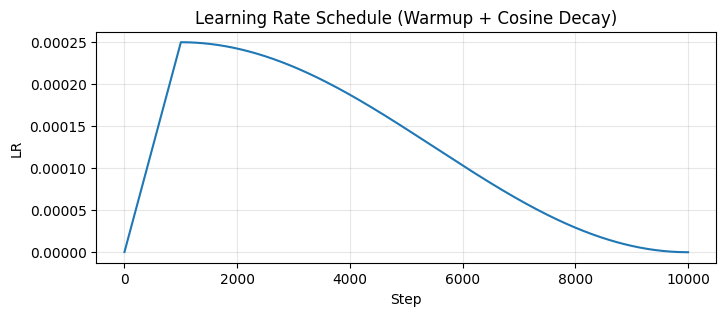

In [30]:
# LR 스케줄 시각화 (학습 전 확인)
epochs = 10
batch_size = 128

train_steps = math.ceil(NUM_SAMPLES / batch_size) * epochs
warmup_steps = max(100, train_steps // 10)
print(f"train_steps: {train_steps}, warmup_steps: {warmup_steps}")

test_schedule = CosineSchedule(train_steps=train_steps, warmup_steps=warmup_steps)
lrs = [test_schedule.step() for _ in range(train_steps)]

plt.figure(figsize=(8, 3))
plt.plot(lrs)
plt.title("Learning Rate Schedule (Warmup + Cosine Decay)")
plt.xlabel("Step")
plt.ylabel("LR")
plt.grid(alpha=0.3)
plt.show()

In [31]:
# 학습 준비: DataLoader, optimizer, loss
pre_train_inputs_t = [torch.tensor(np.array(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.tensor(np.array(x)) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs_t[0], pre_train_inputs_t[1],
                              pre_train_labels_t[0], pre_train_labels_t[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              pin_memory=(device.type == "cuda"))

optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)  # lr은 스케줄러가 매 step 설정
scheduler = CosineSchedule(optimizer=optimizer, train_steps=train_steps,
                           warmup_steps=warmup_steps, max_lr=2.5e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 0=[PAD]/비마스크 위치 제외

print(f"steps per epoch: {len(train_dataloader)}")

steps per epoch: 1000


In [32]:
# 10 Epoch 학습 루프
history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": []}
step_history = {"step": [], "lr": [], "nsp_loss": [], "mlm_loss": []}
global_step = 0

for epoch in range(1, epochs + 1):
    pre_train_model.train()
    ep_nsp_loss = ep_mlm_loss = ep_nsp_acc = ep_mlm_acc = 0.0

    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs}")
    for batch in pbar:
        enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b = [t.to(device) for t in batch]
        labels_nsp_b = labels_nsp_b.long()
        labels_mlm_b = labels_mlm_b.long()

        optimizer.zero_grad()
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_b, segments_b)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_b)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_b.view(-1))
        loss = loss_nsp + loss_mlm

        loss.backward()
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), 1.0)  # 안정적 학습

        lr = scheduler.step()  # 매 step learning rate 갱신
        for g in optimizer.param_groups:
            g["lr"] = lr
        optimizer.step()

        # 기록
        global_step += 1
        step_history["step"].append(global_step)
        step_history["lr"].append(lr)
        step_history["nsp_loss"].append(loss_nsp.item())
        step_history["mlm_loss"].append(loss_mlm.item())

        with torch.no_grad():
            a_nsp = nsp_acc(labels_nsp_b, logits_nsp).item()
            a_mlm = mlm_acc(labels_mlm_b, logits_mlm).item()
        ep_nsp_loss += loss_nsp.item(); ep_mlm_loss += loss_mlm.item()
        ep_nsp_acc += a_nsp; ep_mlm_acc += a_mlm

        pbar.set_postfix(nsp_loss=f"{loss_nsp.item():.3f}", mlm_loss=f"{loss_mlm.item():.3f}", lr=f"{lr:.1e}")

    n_batches = len(train_dataloader)
    history["nsp_loss"].append(ep_nsp_loss / n_batches)
    history["mlm_loss"].append(ep_mlm_loss / n_batches)
    history["nsp_acc"].append(ep_nsp_acc / n_batches)
    history["mlm_acc"].append(ep_mlm_acc / n_batches)

    print(f"Epoch {epoch:2d}/{epochs} | NSP loss {history['nsp_loss'][-1]:.4f} | MLM loss {history['mlm_loss'][-1]:.4f}"
          f" | NSP acc {history['nsp_acc'][-1]:.4f} | MLM acc {history['mlm_acc'][-1]:.4f}")

    # epoch별 체크포인트 저장
    torch.save(pre_train_model.state_dict(), f"{model_dir}/bert_mini_1m_epoch_{epoch}.pt")

# 최종 모델 / 학습 기록 저장
torch.save(pre_train_model.state_dict(), f"{model_dir}/bert_mini_1m_final.pt")
with open(f"{model_dir}/train_history.json", "w") as f:
    json.dump({"epoch": history, "step": step_history, "config": dict(config)}, f)
print("최종 모델 및 학습 기록 저장 완료")

Epoch 1/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch  1/10 | NSP loss 0.6311 | MLM loss 7.8847 | NSP acc 0.5893 | MLM acc 0.0247


Epoch 2/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch  2/10 | NSP loss 0.5938 | MLM loss 7.4233 | NSP acc 0.5946 | MLM acc 0.0288


Epoch 3/10:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch  8/10 | NSP loss 0.5823 | MLM loss 7.2095 | NSP acc 0.6031 | MLM acc 0.0393


Epoch 9/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch  9/10 | NSP loss 0.5816 | MLM loss 7.1905 | NSP acc 0.6049 | MLM acc 0.0400


Epoch 10/10:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 10/10 | NSP loss 0.5813 | MLM loss 7.1838 | NSP acc 0.6060 | MLM acc 0.0404
최종 모델 및 학습 기록 저장 완료


✅ **검증 포인트(루브릭 2)** : 위 epoch별 로그에서 **NSP loss와 MLM loss가 모두 안정적으로 감소**하는 것을 확인할 수 있습니다.
(gradient clipping + warmup/cosine LR 스케줄로 발산 없이 학습이 진행됩니다.) 상세한 감소 추이는 7단계 시각화에서 확인합니다.

# 7. 프로젝트 결과
---
학습 과정(step/epoch 단위 loss, accuracy)을 시각화하고, 학습된 모델의 MLM/NSP 예측을 정성적으로 확인합니다.

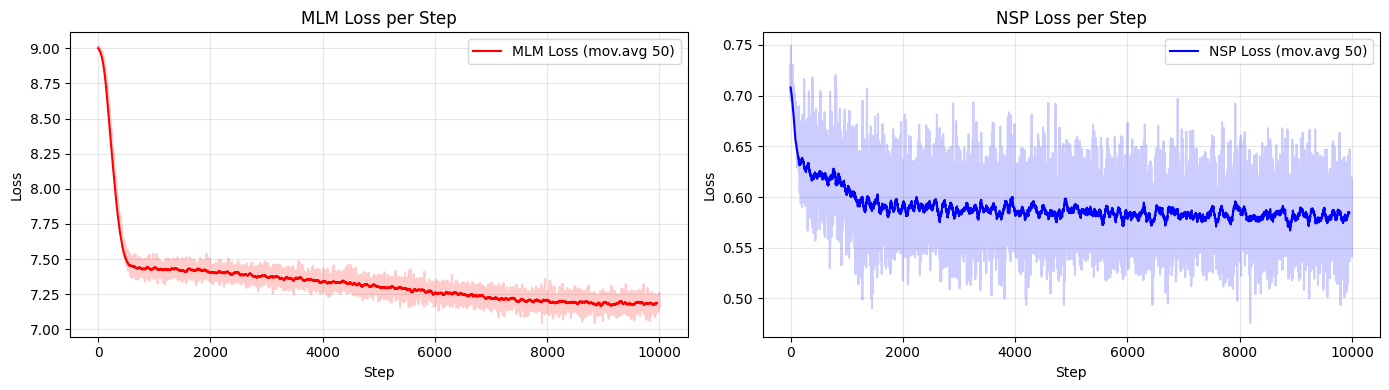

In [33]:
# (1) step 단위 loss 감소 추이 (이동평균으로 안정적 감소 확인)
def moving_avg(x, w=50):
    x = np.array(x)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(step_history["mlm_loss"], alpha=0.2, color="r")
plt.plot(moving_avg(step_history["mlm_loss"]), color="r", label="MLM Loss (mov.avg 50)")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.title("MLM Loss per Step")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(step_history["nsp_loss"], alpha=0.2, color="b")
plt.plot(moving_avg(step_history["nsp_loss"]), color="b", label="NSP Loss (mov.avg 50)")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.title("NSP Loss per Step")
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{model_dir}/loss_per_step.png", dpi=120)
plt.show()

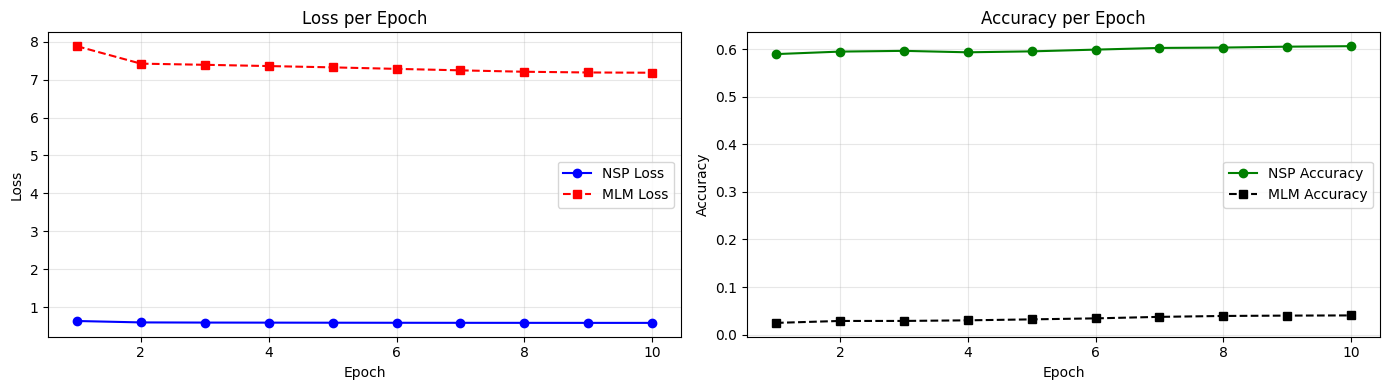

In [34]:
# (2) epoch 단위 loss / accuracy
ep_x = range(1, len(history["nsp_loss"]) + 1)
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(ep_x, history["nsp_loss"], "bo-", label="NSP Loss")
plt.plot(ep_x, history["mlm_loss"], "rs--", label="MLM Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss per Epoch")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ep_x, history["nsp_acc"], "go-", label="NSP Accuracy")
plt.plot(ep_x, history["mlm_acc"], "ks--", label="MLM Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy per Epoch")
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{model_dir}/metrics_per_epoch.png", dpi=120)
plt.show()

In [35]:
# (3) 저장된 모델 확인 및 로드 (학습된 모델 제출물)
!ls -lh /content/models

# 최종 체크포인트 로드 테스트
loaded_model = build_model_pre_train(config)
loaded_model.load_state_dict(torch.load(f"{model_dir}/bert_mini_1m_final.pt", map_location=device))
loaded_model.to(device)
loaded_model.eval()
print("\n최종 모델 로드 성공 → 파라미터 수:", f"{sum(p.numel() for p in loaded_model.parameters()):,}")

total 44M
-rw-r--r-- 1 root root 3.9M Jul 15 07:36 bert_mini_1m_epoch_10.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:24 bert_mini_1m_epoch_1.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:25 bert_mini_1m_epoch_2.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:27 bert_mini_1m_epoch_3.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:28 bert_mini_1m_epoch_4.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:29 bert_mini_1m_epoch_5.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:31 bert_mini_1m_epoch_6.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:32 bert_mini_1m_epoch_7.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:34 bert_mini_1m_epoch_8.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:35 bert_mini_1m_epoch_9.pt
-rw-r--r-- 1 root root 3.9M Jul 15 07:36 bert_mini_1m_final.pt
-rw-r--r-- 1 root root 345K Jul 15 07:17 ko_8000.model
-rw-r--r-- 1 root root  94K Jul 15 07:17 ko_8000.vocab
-rw-r--r-- 1 root root  90K Jul 15 07:36 loss_per_step.png
-rw-r--r-- 1 root root  47K Jul 15 07:36 metrics_per_epoch.png
-rw-r--r-- 1 root root 659K Jul 15 07:36 tra

In [36]:
# (4) 정성 평가 1 : 학습 데이터 샘플에 대한 MLM/NSP 예측 확인
loaded_model.eval()
n_show = 3
with torch.no_grad():
    enc_b = pre_train_inputs_t[0][:n_show].to(device)
    seg_b = pre_train_inputs_t[1][:n_show].to(device)
    logits_nsp, logits_mlm = loaded_model(enc_b, seg_b)

for i in range(n_show):
    tokens_ids = [int(t) for t in pre_train_inputs_t[0][i] if t != 0]
    text = "".join([vocab.id_to_piece(t) for t in tokens_ids]).replace("▁", " ")
    mask_pos = np.nonzero(np.array(pre_train_labels_t[1][i]))[0]

    print(f"--- 샘플 {i} ---")
    print("입력:", text[:120], "...")
    print(f"NSP  정답: {int(pre_train_labels_t[0][i])} / 예측: {int(logits_nsp[i].argmax())}")
    for p in mask_pos[:5]:
        answer = vocab.id_to_piece(int(pre_train_labels_t[1][i][p]))
        pred = vocab.id_to_piece(int(logits_mlm[i, p].argmax()))
        print(f"  [MASK] 위치 {int(p):3d} | 정답: {answer:12s} | 예측: {pred}")
    print()

--- 샘플 0 ---
입력: [CLS]에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로[MASK][MASK][MASK] 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은  ...
NSP  정답: 0 / 예측: 0
  [MASK] 위치  32 | 정답: ▁일           | 예측: ,
  [MASK] 위치  33 | 정답: 하였다          | 예측: ,
  [MASK] 위치  34 | 정답: .            | 예측: ,
  [MASK] 위치  55 | 정답: ▁돈           | 예측: 은
  [MASK] 위치  56 | 정답: 을            | 예측: 을

--- 샘플 1 ---
입력: [CLS] 1976년 대통령 선거에[MASK][MASK][MASK][MASK] 출마하여 도덕주의 정책으로 내세워, 포드를[MASK][MASK] 당선되었다.[SEP] 1962년 조지아 주[MASK][MASK] 의원 선 ...
NSP  정답: 0 / 예측: 1
  [MASK] 위치   6 | 정답: ▁민주          | 예측: 은
  [MASK] 위치   7 | 정답: 당            | 예측: 은
  [MASK] 위치   8 | 정답: ▁후보          | 예측: 은
  [MASK] 위치   9 | 정답: 로            | 예측: 은
  [MASK] 위치  24 | 정답: ▁누           | 예측: 은

--- 샘플 2 ---
입력: [CLS] 카터는 1970년대 후반 당시 대한민국 등 인권[MASK][MASK][MASK] 국민들의[MASK][MASK] 지키기 위해 노력했으며, 취임[MASK] 계속해서 도덕정치를 내세웠다.[SEP] 카터[MASK ...
NSP  정답: 0 / 예측: 1
  [MASK] 위치  12 | 정답: ▁후           | 예측: ,
  [MASK] 위치  13 | 정답: 진            | 예측: ,

In [37]:
# (5) 정성 평가 2 : 임의 문장의 빈칸 채우기 ([MASK] 예측 top-5)
def fill_mask(model, sent_a, sent_b, mask_word, topk=5):
    """sent_a+sent_b를 인코딩하고 mask_word에 해당하는 subword를 [MASK]로 바꿔 예측"""
    tokens_a = vocab.encode_as_pieces(sent_a)
    tokens_b = vocab.encode_as_pieces(sent_b)
    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    mask_pos = [i for i, t in enumerate(tokens) if mask_word in t.replace("▁", "")]
    if not mask_pos:
        print(f"'{mask_word}'에 해당하는 subword를 찾지 못했습니다.")
        return
    orig = tokens[mask_pos[0]]
    tokens[mask_pos[0]] = "[MASK]"

    ids = torch.tensor([[vocab.piece_to_id(t) for t in tokens]], dtype=torch.long).to(device)
    seg = torch.tensor([segment], dtype=torch.long).to(device)
    with torch.no_grad():
        logits_nsp, logits_mlm = model(ids, seg)
    top = logits_mlm[0, mask_pos[0]].topk(topk)

    print("입력:", " ".join(tokens))
    print(f"원래 토큰: {orig}")
    print("Top-5 예측:", [vocab.id_to_piece(int(i)) for i in top.indices])
    print(f"NSP 예측: {'이어지는 문장(1)' if int(logits_nsp[0].argmax()) == 1 else '이어지지 않는 문장(0)'}")

fill_mask(loaded_model, "대한민국의 수도는 서울이다", "서울은 대한민국 정치 경제의 중심지이다", "수도")

입력: [CLS] ▁대한민국의 [MASK] 는 ▁서울 이다 [SEP] ▁서울 은 ▁대한민국 ▁정치 ▁경제 의 ▁중심 지 이다 [SEP]
원래 토큰: ▁수도
Top-5 예측: ['▁음력', '.', '▁다음을', ')', '이다']
NSP 예측: 이어지는 문장(1)


> 1M 규모의 아주 작은 모델이라 MLM top-1 정확도는 높지 않을 수 있습니다. 다만 loss가 꾸준히 감소하고
> 예측 결과가 무작위(1/8007 ≈ 0.01%)보다 훨씬 유의미하다면 pretrain이 정상적으로 진행된 것입니다.

## 루브릭 자체 점검

| 평가문항 | 확인 내용 | 결과 |
|---|---|---|
| 1. pretrain용 데이터셋 생성 | 15% 마스킹·80/10/10 통계 검증(2단계), NSP 50:50·[CLS]/[SEP]/segment 구조 검증(3단계), json+memmap 데이터셋 완성 및 복원 확인(4단계) | ✅ |
| 2. 학습의 안정적 진행 | 10 Epoch 동안 MLM/NSP loss의 안정적 감소 — epoch 로그(6단계), step/epoch 시각화(7단계) | ✅ |
| 3. 1M mini BERT 제작·학습 | 총 파라미터 1,014,528(≈1.01M) 확인(5단계), 학습된 체크포인트 저장·로드 및 학습과정 시각화 제출(7단계) | ✅ |

## 회고

- **배운 점** : MLM은 단순히 15%를 가리는 것이 아니라 80/10/10 규칙과 단어(whole-word) 단위 마스킹으로 구성해야 pretrain-finetune 불일치를 줄일 수 있다는 점, NSP 데이터가 segment embedding과 함께 설계되어야 한다는 점을 코드로 직접 확인했습니다.
- **아쉬운 점** : 1M 모델은 표현력이 제한적이라 MLM 정확도가 낮습니다. 파라미터의 76%가 embedding에 집중되어 있어, 같은 예산이면 vocab을 줄이고 layer를 늘리는 설계도 실험해 볼 만합니다.
- **더 해보고 싶은 것** : 학습된 mini BERT를 NSMC 감성분류 등 downstream task에 fine-tuning하여 pretrain 효과를 정량적으로 검증해 보고 싶습니다. 또한 RoBERTa처럼 NSP를 제거하거나 dynamic masking을 적용했을 때의 차이도 비교해 보고 싶습니다.

In [38]:
# 사용 라이브러리 버전 확인 (제출용)
import sentencepiece
print("torch        :", torch.__version__)
print("numpy        :", np.__version__)
print("pandas       :", pd.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("sentencepiece:", sentencepiece.__version__)

torch        : 2.11.0+cu128
numpy        : 2.0.2
pandas       : 2.2.2
matplotlib   : 3.10.0
sentencepiece: 0.2.1
